## 문제 정의: SMS 스팸 분류

- **목표**: 문자 메시지가 스팸인지 정상(ham)인지 예측
- **문제 유형**: 이진 분류 (spam / ham)
- **입력(X)**: 문자 메시지 텍스트 (자연어)
- **출력(y)**: ham(정상) / spam(스팸)
- **평가 기준**: 정상 문자를 스팸으로 막는 오류(FP)가 치명적
  → spam의 precision 중요 (중요한 문자를 스팸함에 가두면 안 됨)
- **데이터 과제**:
  - 인코딩이 latin-1 (UTF-8 아님)
  - CSV 파싱 오류로 일부 메시지가 여러 컬럼으로 쪼개짐 → 복원 필요
  - 텍스트 → 숫자 변환 필요 (Vectorizer)
- **알고리즘**: 나이브 베이즈 (MultinomialNB) - 텍스트 분류에 강함

In [32]:
import pandas as pd

# encoding='latin-1': 인코딩
df = pd.read_csv("../data/spam.csv", encoding="latin-1")

print(df.shape)
df.head()

(5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [34]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [35]:
df[df["Unnamed: 2"].notna()]

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN
710,ham,Height of Confidence: All the Aeronautics prof...,"this wont even start........ Datz confidence..""",NaN,NaN
899,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
1038,ham,"Edison has rightly said, \A fool can ask more ...",GN,GE,"GNT:-)"""
1127,ham,"Height of \Oh shit....!!\"" situation: A guy th...",".;-):-D""",NaN,NaN
1266,ham,\Hey sorry I didntgive ya a a bellearlier hunny,just been in bedbut mite go 2 thepub l8tr if u...,NaN,NaN
1384,ham,"Storming msg: Wen u lift d phne, u say \HELLO\...","bt not his girlfrnd... G o o d n i g h t . . .@""",NaN,NaN


### Unnamed 컬럼: 버리지 않고 복원한다

`df.info()`에서 `Unnamed: 2/3/4`에 각각 50/12/6개의 값이 있었다.
이는 결측치가 아니라 **CSV 파싱 오류**다 — 메시지 안의 쉼표(,)와 깨진 따옴표
때문에 pandas가 한 메시지를 여러 컬럼으로 잘못 쪼갰다.
(pandas 문서: 따옴표 안에 쉼표가 있으면 read_csv가 컬럼을 잘못 나눌 수 있음)

예) 행 281: 원래 한 문장이 v2 → Unnamed 2 → 3 → 4로 흩어짐
> "Wen u miss someone, the person is definitely special... why to miss them, just Keep-in-touch gdeve.."

**결정: 행을 버리지 않고, 흩어진 조각을 순서대로 합쳐 원문을 복원한다.**

근거 (결측치 처리 표준):
- 행을 버리는 것(listwise deletion)은 결측이 **MCAR(완전 무작위)**일 때만
  편향이 없다. (The Analysis Factor / GeeksforGeeks)
- 그러나 손상된 50개는 "쉼표가 많은 긴 메시지 + 대부분 ham"으로
  **특정 성질에 쏠려 있어 MCAR이 아니다** → 버리면 편향 발생.
- 또한 조각이 v2→2→3→4 순서로 보존돼 있어 **복원이 가능**하다.
  복원하면 데이터 손실도, 편향도 없다.
- 검증: 복원 후 모든 행이 온전한 텍스트를 가짐 (빈 문자열 0).


In [36]:
# 흩어진 텍스트 조각을 원래 순서대로 합쳐 원문 복원
text_cols = ["v2", "Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]

# fillna(""): NaN을 빈 문자열로 (합칠 때 "nan"이 끼지 않게)
# agg(" ".join, axis=1): 각 행의 4칸을 공백으로 이어붙임
# str.strip(): 합치면서 생긴 앞뒤 공백 제거
df["text"] = df[text_cols].fillna("").agg(" ".join, axis=1).str.strip()

df = df[["v1", "text"]].rename(columns={"v1": "label"})

print(df.shape)
print(df.isnull().sum())
df["label"].value_counts()

(5572, 2)
label    0
text     0
dtype: int64


label
ham     4825
spam     747
Name: count, dtype: int64

In [37]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5572 non-null   str  
 1   text    5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


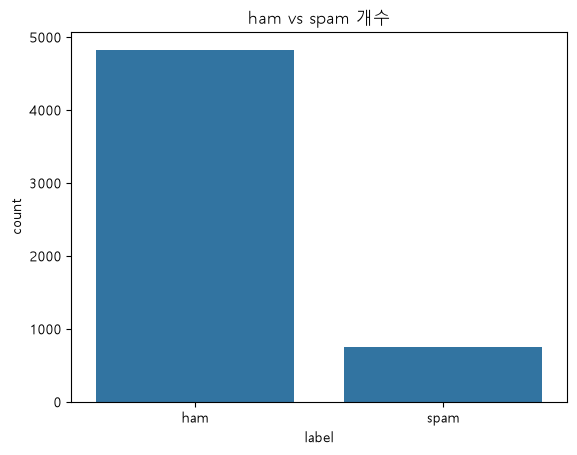

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows 기본 폰트)
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

# 1) 클래스 분포 - value_counts를 그림으로 (불균형 시각적 확인)
sns.countplot(data=df, x="label")
plt.title("ham vs spam 개수")
plt.show()

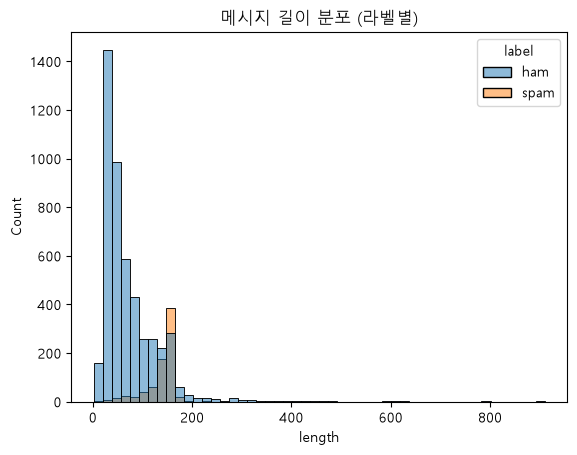

In [40]:
# 2) 메시지 길이 분포 - 스팸이 더 긴가? (피처 통찰)
df["length"] = df["text"].str.len()

sns.histplot(data=df, x="length", hue="label", bins=50)
plt.title("메시지 길이 분포 (라벨별)")
plt.show()

In [41]:
# map: 문자 라벨을 숫자로 (ham→0, spam→1)
# spam을 1(양성)로 두면 이후 precision/recall이 "스팸 기준"으로 읽힘
df["target"] = df["label"].map({"ham": 0, "spam": 1})

X = df["text"] # 입력: 텍스트
y = df["target"] # 출력: 0/1

df[["label", "target"]].head()

,label,target
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts()) # train의 ham/spam 분포 확인

(4457,) (1115,)
target
0    3859
1     598
Name: count, dtype: int64


In [43]:
df.head()

,label,text,length,target
0,ham,"Go until jurong point, crazy.. Available only ...",111,0
1,ham,Ok lar... Joking wif u oni...,29,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,1
3,ham,U dun say so early hor... U c already then say...,49,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,0


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [45]:
pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("nb", MultinomialNB()),
])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
pred

array([0, 0, 0, ..., 0, 0, 0], shape=(1115,))

In [46]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, target_names=["ham", "spam"]))

accuracy: 0.9838565022421525
[[961   5]
 [ 13 136]]
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.91      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [49]:
# test 결과를 보기 좋게 DataFrame으로 모음
# X_test는 원본 인덱스를 유지하므로 df에서 원문을 가져올 수 있음
results = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "pred": pred,
})
results.head()

,text,actual,pred
2826,"Oh right, ok. I'll make sure that i do loads o...",0,0
3695,I am in tirupur. call you da.,0,0
3906,No that just means you have a fat head,0,0
575,"You have won ?1,000 cash or a ?2,000 prize! To...",1,1
2899,Come aftr &lt;DECIMAL&gt; ..now i m cleaning ...,0,0


In [50]:
# actual=1 and pred=0
missed_spam = results[(results["actual"] == 1) & (results["pred"] == 0)]

print(f"놓친 스팸: {len(missed_spam)}개")
for t in missed_spam["text"]:
    print("-", t)

놓친 스팸: 13개
- FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv
- Sorry I missed your call let's talk when you have the time. I'm on 07090201529
- Latest News! Police station toilet stolen, cops have nothing to go on!
- Can U get 2 phone NOW? I wanna chat 2 set up meet Call me NOW on 09096102316 U can cum here 2moro Luv JANE xx Callså£1/minmoremobsEMSPOBox45PO139WA
- Hi babe its Jordan, how r u? Im home from abroad and lonely, text me back if u wanna chat xxSP visionsms.com Text stop to stopCost 150p 08712400603
- More people are dogging in your area now. Call 09090204448 and join like minded guys. Why not arrange 1 yourself. There's 1 this evening. Aå£1.50 minAPN LS278BB
- For sale - arsenal dartboard. Good condition but no doubles or trebles!
- Email AlertFrom: Jeri StewartSize: 2KBSubject: Low-cost prescripiton drvgsTo listen to email call 123
- Download as many ringtones as u like no r

In [51]:
# actual=0 and pred=1
false_alarm = results[(results["actual"] == 0) & (results["pred"] == 1)]

print(f"오경보(정상 → 스팸): {len(false_alarm)}개")
for t in false_alarm["text"]:
    print("-", t)

오경보(정상 → 스팸): 5개
- Anytime...
- Waiting for your call.
- Unlimited texts. Limited minutes.
- Nokia phone is lovly..
- We have sent JD for Customer Service cum Accounts Executive to ur mail id, For details contact us
